In [ ]:
import plotly.express as px
import geopandas as gpd
import pandas as pd 


In [2]:
import pandas as pd 
nazioni_migranti_csv = pd.read_csv("https://raw.githubusercontent.com/ondata/liberiamoli-tutti/refs/heads/main/sbarchi-migranti/dati/nazionalita.csv")

nazioni_migranti_csv['Anno'] = nazioni_migranti_csv['Data_Report'].str[:4].astype(int)

nazioni_per_anno = nazioni_migranti_csv.groupby('Anno')['Nazione'].unique()

nazioni_per_anno


Anno
2019    [Algeria, Bangladesh, Costa d'Avorio, Guinea, ...
2020    [Afghanistan, Algeria, Camerun, Costa d'Avorio...
2021    [Afghanistan, Bangladesh, Costa d'Avorio, Egit...
2022    [Afghanistan, Algeria, Bangladesh, Costa d'Avo...
2023    [Afghanistan, Bangladesh, Camerun, Costa d'Avo...
2024    [Bangladesh, Costa d'Avorio, Egitto, Gambia, G...
2025    [Algeria, Bangladesh, Egitto, Eritrea, Etiopia...
Name: Nazione, dtype: object

In [51]:
nazioni_migranti_csv[nazioni_migranti_csv['Nazione'] == 'Turchia']


,Data_Report,Nazione,ISO_3166-1,Valore,Anno,ADMIN
350,2021-01-15,Turchia,TR,2,2021,Turkey


In [ ]:
# TODO -> CORREGGERE LA FUNZIONE -> NON FUNZIONA CORRETTAMENTE, ES: BANGLADESH È MESSO IN COMUNE MA NEL 2020 MANCA

# Verifica delle nazioni che non ci sono in altri anni
nazioni_uniche = set()
nazioni_comuni = set(nazioni_per_anno[2019])

for anno, paesi in nazioni_per_anno.items():
    nazioni_comuni.intersection_update(paesi)
    nazioni_uniche.update(paesi)

nazioni_non_comuni = nazioni_uniche - nazioni_comuni
print("Nazioni non comuni:", nazioni_non_comuni)

# Verifica delle nazioni che non ci sono in ogni altro anno
nazioni_non_comuni_per_anno = {}

for anno, paesi in nazioni_per_anno.items():
    nazioni_non_comuni_per_anno[anno] = nazioni_uniche - set(paesi)

print("Nazioni non comuni per anno:", nazioni_non_comuni_per_anno)
print("nazioni_comuni: ", nazioni_comuni)

Nazioni non comuni: {'Senegal', 'Marocco', 'Turchia', 'Etiopia', 'Iraq', 'Nigeria', 'Camerun', 'Siria', 'Mali', 'Gambia', 'Burkina Faso', 'Eritrea', 'Iran', 'Afghanistan', 'Egitto', 'Somalia', 'Ucraina', 'Algeria'}
Nazioni non comuni per anno: {2019: {'Senegal', 'Turchia', 'Etiopia', 'Camerun', 'Siria', 'Mali', 'Gambia', 'Burkina Faso', 'Eritrea', 'Egitto', 'Ucraina', 'Afghanistan'}, 2020: {'Senegal', 'Turchia', 'Etiopia', 'Siria', 'Gambia', 'Burkina Faso', 'Eritrea'}, 2021: {'Nigeria', 'Gambia', 'Burkina Faso', 'Somalia', 'Ucraina'}, 2022: {'Senegal', 'Marocco', 'Turchia', 'Iraq', 'Etiopia', 'Mali', 'Gambia', 'Burkina Faso', 'Somalia', 'Ucraina'}, 2023: {'Senegal', 'Marocco', 'Turchia', 'Iraq', 'Etiopia', 'Nigeria', 'Gambia', 'Iran', 'Somalia', 'Ucraina', 'Algeria'}, 2024: {'Senegal', 'Marocco', 'Turchia', 'Iraq', 'Nigeria', 'Camerun', 'Burkina Faso', 'Iran', 'Afghanistan', 'Somalia', 'Ucraina', 'Algeria'}, 2025: {'Senegal', 'Turchia', 'Iraq', 'Camerun', 'Gambia', 'Burkina Faso', 'Ucr

In [4]:
for anno, seq in nazioni_per_anno.items():
    print(seq)
    print(anno)
    anno = str(anno)
    for nazione in seq:
        print(nazione, nazioni_migranti_csv.query("Nazione == @nazione and Data_Report == @anno+'-12-31'")['Valore'])

['Algeria' 'Bangladesh' "Costa d'Avorio" 'Guinea' 'Iran' 'Iraq' 'Marocco'
 'Pakistan' 'Sudan' 'Tunisia' 'altre' 'Nigeria' 'Somalia']
2019
Algeria 66    1009
Name: Valore, dtype: int64
Bangladesh 67    602
Name: Valore, dtype: int64
Costa d'Avorio 68    1139
Name: Valore, dtype: int64
Guinea 69    295
Name: Valore, dtype: int64
Iran 70    481
Name: Valore, dtype: int64
Iraq 71    972
Name: Valore, dtype: int64
Marocco Series([], Name: Valore, dtype: int64)
Pakistan 72    1180
Name: Valore, dtype: int64
Sudan 74    446
Name: Valore, dtype: int64
Tunisia 75    2654
Name: Valore, dtype: int64
altre 76    2423
Name: Valore, dtype: int64
Nigeria Series([], Name: Valore, dtype: int64)
Somalia 73    270
Name: Valore, dtype: int64
['Afghanistan' 'Algeria' 'Camerun' "Costa d'Avorio" 'Guinea' 'Iran' 'Iraq'
 'Mali' 'Tunisia' 'Ucraina' 'altre' 'Bangladesh' 'Marocco' 'Nigeria'
 'Somalia' 'Sudan' 'Egitto' 'Pakistan']
2020
Afghanistan 330    1009
Name: Valore, dtype: int64
Algeria 331    1458
Name: Va

In [5]:
world_country_geom = gpd.read_file("/home/enrique/github/data-science-unitn/geospatial-analysis/data/ne_10m_admin_0_countries.shp")

In [25]:
# world_country_geom.head()
world_country_geom[world_country_geom['ADMIN'].str.contains('T')]['ADMIN']

18        United Republic of Tanzania
42                         Tajikistan
65                             Turkey
72                            Tunisia
110                          Thailand
118                        East Timor
142                      Turkmenistan
150                              Togo
174                         Bir Tawil
186                       The Bahamas
187          Turks and Caicos Islands
188                            Taiwan
198               Trinidad and Tobago
220             São Tomé and Principe
228          Indian Ocean Territories
229    British Indian Ocean Territory
233                             Tonga
237                            Tuvalu
Name: ADMIN, dtype: object

EPSG:4326


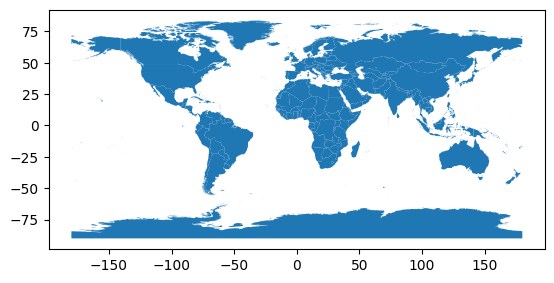

In [7]:
world_country_geom.plot()
print(world_country_geom.crs)

In [8]:
!pip install googletrans

Defaulting to user installation because normal site-packages is not writeable


In [9]:
from googletrans import Translator
translate = await Translator().translate('Siria')
print(translate)

Translated(src=it, dest=en, text=Syria, pronunciation=Syria, extra_data="{'translat...")


In [49]:
nazioni_migranti_csv['Nazione'].unique()

array(['Algeria', 'Bangladesh', "Costa d'Avorio", 'Guinea', 'Iran',
       'Iraq', 'Marocco', 'Pakistan', 'Sudan', 'Tunisia', 'altre',
       'Nigeria', 'Somalia', 'Afghanistan', 'Camerun', 'Mali', 'Ucraina',
       'Egitto', 'Turchia', 'Eritrea', 'Etiopia', 'Senegal', 'Siria',
       'Burkina Faso', 'Gambia'], dtype=object)

In [ ]:
from googletrans import Translator

for nomi_nazioni_it in nazioni_migranti_csv['Nazione'].unique():
    print(nomi_nazioni_it)
    translate_en = await Translator().translate(nomi_nazioni_it)
    print(translate_en.text)
    nazioni_migranti_csv.loc[nazioni_migranti_csv['Nazione'] == nomi_nazioni_it, 'ADMIN'] = translate_en.text

print(nazioni_migranti_csv['ADMIN'].unique())

# -> Modifica manuale per la Turchia, da Türkiye a Turkey
nazioni_migranti_csv.loc[nazioni_migranti_csv['ADMIN'] == 'Türkiye', 'ADMIN'] = 'Turkey'
print(nazioni_migranti_csv['ADMIN'].unique())


Algeria
Algeria
Bangladesh
Bangladesh
Costa d'Avorio
Ivory Coast
Guinea
Guinea
Iran
Iran
Iraq
Iraq
Marocco
Morocco
Pakistan
Pakistan
Sudan
Sudan
Tunisia
Tunisia
altre
other
Nigeria
Nigeria
Somalia
Somalia
Afghanistan
Afghanistan
Camerun
Cameroon
Mali
Mali
Ucraina
Ukraine
Egitto
Egypt
Turchia
Türkiye
Eritrea
Eritrea
Etiopia
Ethiopia
Senegal
Senegal
Siria
Syria
Burkina Faso
Burkina Faso
Gambia
Gambia
['Algeria' 'Bangladesh' 'Ivory Coast' 'Guinea' 'Iran' 'Iraq' 'Morocco'
 'Pakistan' 'Sudan' 'Tunisia' 'other' 'Nigeria' 'Somalia' 'Afghanistan'
 'Cameroon' 'Mali' 'Ukraine' 'Egypt' 'Türkiye' 'Eritrea' 'Ethiopia'
 'Senegal' 'Syria' 'Burkina Faso' 'Gambia']
['Algeria' 'Bangladesh' 'Ivory Coast' 'Guinea' 'Iran' 'Iraq' 'Morocco'
 'Pakistan' 'Sudan' 'Tunisia' 'other' 'Nigeria' 'Somalia' 'Afghanistan'
 'Cameroon' 'Mali' 'Ukraine' 'Egypt' 'Turkey' 'Eritrea' 'Ethiopia'
 'Senegal' 'Syria' 'Burkina Faso' 'Gambia']


In [28]:
import geopandas as gpd

nazioni_migranti_gdf = nazioni_migranti_csv.merge(
    world_country_geom,
    on="ADMIN",
    how="left"
).set_index("ADMIN")

# Converti in un vero GeoDataFrame
nazioni_migranti_gdf = gpd.GeoDataFrame(
    nazioni_migranti_gdf,
    geometry="geometry",
    crs=world_country_geom.crs   # eredita il CRS dal geodataframe originale
)


In [29]:
nazioni_migranti_20190930_geodf = nazioni_migranti_gdf[nazioni_migranti_gdf['Data_Report'] == '2019-09-30']
nazioni_migranti_20190930_geodf


,Data_Report,Nazione,ISO_3166-1,Valore,Anno,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
ADMIN,,,,,,,,,,,,,,,,,,,,,
Algeria,2019-09-30,Algeria,DZ,723,2019,Admin-0 country,0.0,3.0,Algeria,DZA,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209..."
Bangladesh,2019-09-30,Bangladesh,BD,259,2019,Admin-0 country,0.0,3.0,Bangladesh,BGD,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21..."
Ivory Coast,2019-09-30,Costa d'Avorio,CI,864,2019,Admin-0 country,0.0,3.0,Ivory Coast,CIV,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10...."
Guinea,2019-09-30,Guinea,GN,187,2019,Admin-0 country,0.0,3.0,Guinea,GIN,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,..."
Iran,2019-09-30,Iran,IR,188,2019,Admin-0 country,0.0,2.0,Iran,IRN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39...."
Iraq,2019-09-30,Iraq,IQ,582,2019,Admin-0 country,0.0,3.0,Iraq,IRQ,...,None,None,None,None,None,None,None,None,None,"POLYGON ((44.76614 37.14192, 44.75254 37.11314..."
Morocco,2019-09-30,Marocco,MA,132,2019,Admin-0 country,0.0,3.0,Morocco,MAR,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,..."
Pakistan,2019-09-30,Pakistan,PK,922,2019,Admin-0 country,0.0,2.0,Pakistan,PAK,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36..."
Sudan,2019-09-30,Sudan,SD,344,2019,Admin-0 country,0.0,3.0,Sudan,SDN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11..."


In [30]:
nazioni_migranti_20190930_geodf

,Data_Report,Nazione,ISO_3166-1,Valore,Anno,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
ADMIN,,,,,,,,,,,,,,,,,,,,,
Algeria,2019-09-30,Algeria,DZ,723,2019,Admin-0 country,0.0,3.0,Algeria,DZA,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209..."
Bangladesh,2019-09-30,Bangladesh,BD,259,2019,Admin-0 country,0.0,3.0,Bangladesh,BGD,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21..."
Ivory Coast,2019-09-30,Costa d'Avorio,CI,864,2019,Admin-0 country,0.0,3.0,Ivory Coast,CIV,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10...."
Guinea,2019-09-30,Guinea,GN,187,2019,Admin-0 country,0.0,3.0,Guinea,GIN,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,..."
Iran,2019-09-30,Iran,IR,188,2019,Admin-0 country,0.0,2.0,Iran,IRN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39...."
Iraq,2019-09-30,Iraq,IQ,582,2019,Admin-0 country,0.0,3.0,Iraq,IRQ,...,None,None,None,None,None,None,None,None,None,"POLYGON ((44.76614 37.14192, 44.75254 37.11314..."
Morocco,2019-09-30,Marocco,MA,132,2019,Admin-0 country,0.0,3.0,Morocco,MAR,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,..."
Pakistan,2019-09-30,Pakistan,PK,922,2019,Admin-0 country,0.0,2.0,Pakistan,PAK,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36..."
Sudan,2019-09-30,Sudan,SD,344,2019,Admin-0 country,0.0,3.0,Sudan,SDN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11..."


In [31]:
type(nazioni_migranti_20190930_geodf['geometry'])
type(nazioni_migranti_20190930_geodf)
print(nazioni_migranti_20190930_geodf.crs)

EPSG:4326


In [32]:
import json
from shapely.geometry import shape

nazioni_migranti_20190930_geodf.index = nazioni_migranti_20190930_geodf.index.astype(str)

geojson_nazioni = json.loads(nazioni_migranti_20190930_geodf.to_json())

fig_nazioni_migranti_20190930_geodf = px.choropleth_map(nazioni_migranti_20190930_geodf,
                           geojson=geojson_nazioni,
                           locations=nazioni_migranti_20190930_geodf['Nazione'],
                           color="Valore",
                           center={"lat": 41.9028, "lon": 12.4964},
                           #map_style="mercator",
                           zoom=4.5)
fig_nazioni_migranti_20190930_geodf.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})

fig_nazioni_migranti_20190930_geodf.show()
# fig_nazioni_migranti_20190930_geodf.to_html('mappa_nazioni.html')

In [33]:
# TODO -> TRASFORMARE IL GDF IN FORMATO layer long

len(nazioni_migranti_gdf['Data_Report'].unique())
nazioni_migranti_gdf.head(10)
len(nazioni_migranti_gdf['ISO_3166-1'].unique())
type(nazioni_migranti_gdf)

print('ADMIN' in nazioni_migranti_gdf.columns)  # Verifica se 'ADMIN' è una colonna
print('ADMIN' in nazioni_migranti_gdf.index.names)  # Verifica se 'ADMIN' è un indice
# RESET DELL'INDICE ADMIN
nazioni_migranti_gdf = nazioni_migranti_gdf.reset_index()


False
True


In [34]:
nazioni_migranti_gdf['ADMIN']

0           Algeria
1        Bangladesh
2       Ivory Coast
3            Guinea
4              Iran
           ...     
1614          Syria
1615        Somalia
1616          Sudan
1617        Tunisia
1618          other
Name: ADMIN, Length: 1619, dtype: object

In [35]:
import numpy as np
len(nazioni_migranti_gdf['ADMIN'].unique())
nazioni_migranti_gdf_wide = gpd.GeoDataFrame()
nazioni_migranti_gdf_wide['ADMIN'] = nazioni_migranti_gdf['ADMIN'].unique()

# Assign geometries to each unique value in the 'ADMIN' column
for nazioni_admin_en in nazioni_migranti_gdf['ADMIN'].unique():
    geometry = nazioni_migranti_gdf.loc[nazioni_migranti_gdf['ADMIN'] == nazioni_admin_en, 'geometry'].iloc[0]
    nazioni_migranti_gdf_wide.loc[nazioni_migranti_gdf_wide['ADMIN'] == nazioni_admin_en, 'geometry'] = geometry

nazioni_migranti_gdf_wide

/var/data/python/lib/python3.12/site-packages/pandas/core/indexing.py:1881: FutureWarning:

You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.



,ADMIN,geometry
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209..."
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21..."
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10...."
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,..."
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39...."
5,Iraq,"POLYGON ((44.76614 37.14192, 44.75254 37.11314..."
6,Morocco,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,..."
7,Pakistan,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36..."
8,Sudan,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11..."
9,Tunisia,"MULTIPOLYGON (((11.50511 33.18123, 11.50605 33..."


<Axes: >

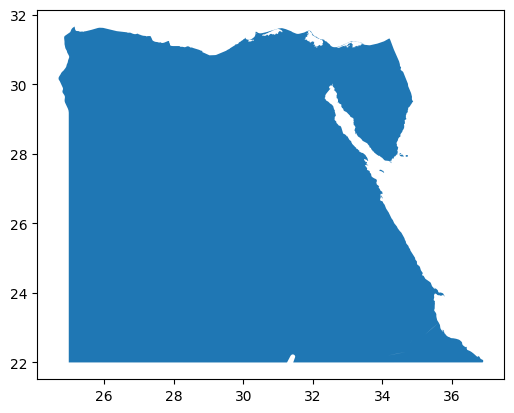

In [36]:
nazioni_migranti_gdf_wide[nazioni_migranti_gdf_wide['ADMIN'] == 'Egypt'].plot()

In [37]:
for nazioni_data_report in nazioni_migranti_gdf['Data_Report'].unique():# ['2019-09-30', '2019-10-15']: # 
    for nazioni_admin_en in nazioni_migranti_gdf['ADMIN'].unique():
        val = nazioni_migranti_gdf.query("ADMIN == @nazioni_admin_en and Data_Report == @nazioni_data_report")["Valore"]
        val = val.iat[0] if not val.empty else np.nan
        nazioni_migranti_gdf_wide.loc[nazioni_migranti_gdf_wide['ADMIN'] == nazioni_admin_en, nazioni_data_report] = val

nazioni_migranti_gdf_wide

/var/data/python/lib/python3.12/site-packages/geopandas/geodataframe.py:1981: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/data/python/lib/python3.12/site-packages/geopandas/geodataframe.py:1981: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/data/python/lib/python3.12/site-packages/geopandas/geodataframe.py:1981: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1)

,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",723.0,786.0,944.0,952.0,982.0,1005.0,1009.0,111.0,...,NaN,NaN,NaN,472.0,548.0,597.0,598.0,658.0,793.0,920.0
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",259.0,325.0,383.0,435.0,520.0,581.0,602.0,NaN,...,5796.0,6951.0,7642.0,8738.0,9733.0,10602.0,11863.0,12086.0,13105.0,14448.0
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",864.0,942.0,973.0,1044.0,1120.0,1135.0,1139.0,73.0,...,NaN,NaN,NaN,325.0,376.0,424.0,452.0,484.0,517.0,532.0
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",187.0,190.0,208.0,236.0,277.0,281.0,295.0,16.0,...,NaN,333.0,504.0,584.0,660.0,829.0,853.0,1050.0,1089.0,1094.0
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",188.0,214.0,375.0,388.0,403.0,434.0,481.0,48.0,...,NaN,NaN,NaN,401.0,528.0,597.0,830.0,867.0,1065.0,1319.0
5,Iraq,"POLYGON ((44.76614 37.14192, 44.75254 37.11314...",582.0,620.0,777.0,805.0,821.0,871.0,972.0,62.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Morocco,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,...",132.0,152.0,190.0,NaN,NaN,253.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Pakistan,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36...",922.0,997.0,1094.0,1142.0,1180.0,1180.0,1180.0,NaN,...,1675.0,2148.0,2306.0,2439.0,2619.0,2749.0,2962.0,2981.0,3086.0,3383.0
8,Sudan,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11...",344.0,344.0,356.0,358.0,440.0,444.0,446.0,NaN,...,564.0,634.0,727.0,905.0,988.0,1178.0,1400.0,1663.0,2016.0,2523.0
9,Tunisia,"MULTIPOLYGON (((11.50511 33.18123, 11.50605 33...",2087.0,2349.0,2555.0,2557.0,2642.0,2654.0,2654.0,17.0,...,246.0,295.0,NaN,334.0,558.0,648.0,662.0,856.0,1070.0,1173.0


<Axes: >

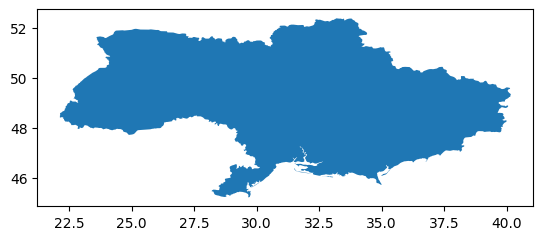

In [38]:
nazioni_migranti_gdf_wide[nazioni_migranti_gdf_wide['ADMIN'] == 'Ukraine'].plot()

In [39]:
nazioni_migranti_gdf_wide.crs = nazioni_migranti_gdf.crs
print(nazioni_migranti_gdf_wide.crs)
nazioni_migranti_gdf_wide.head()


EPSG:4326


,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",723.0,786.0,944.0,952.0,982.0,1005.0,1009.0,111.0,...,NaN,NaN,NaN,472.0,548.0,597.0,598.0,658.0,793.0,920.0
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",259.0,325.0,383.0,435.0,520.0,581.0,602.0,NaN,...,5796.0,6951.0,7642.0,8738.0,9733.0,10602.0,11863.0,12086.0,13105.0,14448.0
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",864.0,942.0,973.0,1044.0,1120.0,1135.0,1139.0,73.0,...,NaN,NaN,NaN,325.0,376.0,424.0,452.0,484.0,517.0,532.0
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",187.0,190.0,208.0,236.0,277.0,281.0,295.0,16.0,...,NaN,333.0,504.0,584.0,660.0,829.0,853.0,1050.0,1089.0,1094.0
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",188.0,214.0,375.0,388.0,403.0,434.0,481.0,48.0,...,NaN,NaN,NaN,401.0,528.0,597.0,830.0,867.0,1065.0,1319.0


In [40]:
nazioni_migranti_gdf_wide.crs = nazioni_migranti_gdf.crs
print(nazioni_migranti_gdf_wide.crs)
nazioni_migranti_gdf_wide.head()


EPSG:4326


,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",723.0,786.0,944.0,952.0,982.0,1005.0,1009.0,111.0,...,NaN,NaN,NaN,472.0,548.0,597.0,598.0,658.0,793.0,920.0
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",259.0,325.0,383.0,435.0,520.0,581.0,602.0,NaN,...,5796.0,6951.0,7642.0,8738.0,9733.0,10602.0,11863.0,12086.0,13105.0,14448.0
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",864.0,942.0,973.0,1044.0,1120.0,1135.0,1139.0,73.0,...,NaN,NaN,NaN,325.0,376.0,424.0,452.0,484.0,517.0,532.0
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",187.0,190.0,208.0,236.0,277.0,281.0,295.0,16.0,...,NaN,333.0,504.0,584.0,660.0,829.0,853.0,1050.0,1089.0,1094.0
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",188.0,214.0,375.0,388.0,403.0,434.0,481.0,48.0,...,NaN,NaN,NaN,401.0,528.0,597.0,830.0,867.0,1065.0,1319.0


<Axes: >

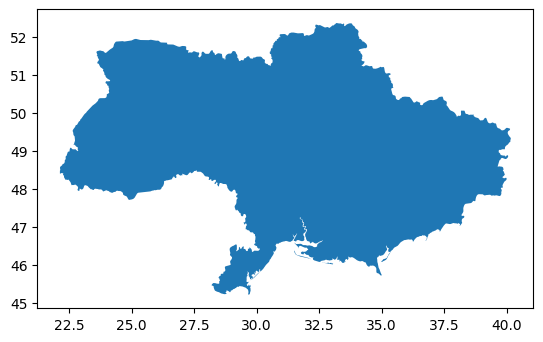

In [41]:
nazioni_migranti_gdf_wide[nazioni_migranti_gdf_wide['ADMIN'] == 'Ukraine'].plot()

In [42]:
!pip install leafmap

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# from leafmap import maplibregl
import leafmap

In [44]:
m = leafmap.Map()

In [ ]:
legend_dict = {
    "[ 0,  250]": "#e6f3ff",
    "( 250,  500]": "#deebf7",
    "( 500,  1000]": "#9ecae1",
    "( 1000,  2500]": "#4292c6",
    "( 2500, 5000]": "#2171b5",
    "( 5000, 20000]": "#084594",
    "Nodata": "#f0f0f0",
}

In [46]:
gdf = leafmap.color_code_dataframe(nazioni_migranti_gdf_wide, legend_dict=legend_dict)
gdf.head(2)


,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",#deebf7,#deebf7,#deebf7,#deebf7,#9ecae1,#9ecae1,#9ecae1,#f0f0f0,...,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594


In [47]:

m.add_gdf_time_slider(gdf, time_interval=0.05, zoom_to_layer=True)
m.add_legend(title="Nazioni di provenienza dichiarate", legend_dict=legend_dict)


### Map Migrants nationality

In [48]:
m

Map(center=[np.float64(25.33632314350006), np.float64(37.553405189000046)], controls=(ZoomControl(options=['po…

In [35]:
m.save('01B_migrant_nationality-raw.html')

In [ ]:
m.save('map.gif')

In [ ]:
import leafmap.foliumap as lf_foliummap

lf_foliummap.Map()

In [ ]:
# DOMANDE -> 1. NEL CORNO D'AFRICA, TRA ERITREA,ETIOPIA E SOMALIA C'È QUALCHE ALTRO PAESE O È UNA ZONA CONTESA?


In [ ]:
m_egypt = leafmap.Map()

In [ ]:
m_egypt.add_gdf_time_slider(gdf[gdf['ADMIN'] == 'Egypt'], time_interval=0.05, zoom_to_layer=True)
m_egypt.add_legend(title="Nazioni di provenienza dichiarate (Ukraine)", legend_dict=legend_dict)

In [ ]:
m_egypt

Map(center=[np.float64(26.825424706000064), np.float64(30.79376163350011)], controls=(ZoomControl(options=['po…

In [52]:
gdf

,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",#deebf7,#deebf7,#deebf7,#deebf7,#9ecae1,#9ecae1,#9ecae1,#f0f0f0,...,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#9ecae1,#9ecae1
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",#e6f3ff,#e6f3ff,#e6f3ff,#e6f3ff,#deebf7,#deebf7,#deebf7,#e6f3ff,...,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",#e6f3ff,#e6f3ff,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6
5,Iraq,"POLYGON ((44.76614 37.14192, 44.75254 37.11314...",#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0
6,Morocco,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,...",#e6f3ff,#e6f3ff,#e6f3ff,#f0f0f0,#f0f0f0,#deebf7,#f0f0f0,#f0f0f0,...,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0
7,Pakistan,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36...",#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#4292c6,#f0f0f0,...,#4292c6,#4292c6,#4292c6,#4292c6,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5
8,Sudan,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11...",#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#f0f0f0,...,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#2171b5
9,Tunisia,"MULTIPOLYGON (((11.50511 33.18123, 11.50605 33...",#4292c6,#4292c6,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5,#e6f3ff,...,#e6f3ff,#deebf7,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6


In [53]:
m_total = leafmap.Map()

In [54]:
gdf[gdf.geometry.notnull()]

,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",#deebf7,#deebf7,#deebf7,#deebf7,#9ecae1,#9ecae1,#9ecae1,#f0f0f0,...,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594,#084594
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#9ecae1,#9ecae1
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",#e6f3ff,#e6f3ff,#e6f3ff,#e6f3ff,#deebf7,#deebf7,#deebf7,#e6f3ff,...,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",#e6f3ff,#e6f3ff,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6
5,Iraq,"POLYGON ((44.76614 37.14192, 44.75254 37.11314...",#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#e6f3ff,...,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0
6,Morocco,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,...",#e6f3ff,#e6f3ff,#e6f3ff,#f0f0f0,#f0f0f0,#deebf7,#f0f0f0,#f0f0f0,...,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0,#f0f0f0
7,Pakistan,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36...",#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#4292c6,#f0f0f0,...,#4292c6,#4292c6,#4292c6,#4292c6,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5
8,Sudan,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11...",#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#deebf7,#f0f0f0,...,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6,#4292c6,#4292c6,#2171b5
9,Tunisia,"MULTIPOLYGON (((11.50511 33.18123, 11.50605 33...",#4292c6,#4292c6,#2171b5,#2171b5,#2171b5,#2171b5,#2171b5,#e6f3ff,...,#e6f3ff,#deebf7,#f0f0f0,#deebf7,#9ecae1,#9ecae1,#9ecae1,#9ecae1,#4292c6,#4292c6


In [55]:
m_total.add_gdf_time_slider(gdf[gdf.geometry.notnull()], time_interval=0.05, zoom_to_layer=True)
m_total.add_legend(title="Nazioni di provenienza dichiarate (Ukraine)", legend_dict=legend_dict)

In [56]:
m_total

Map(center=[np.float64(25.33632314350006), np.float64(37.553405189000046)], controls=(ZoomControl(options=['po…

In [ ]:
m_total.to_html('nazioni_map_total.html')

In [59]:
nazioni_migranti_csv['Data_Report'].unique()

array(['2019-09-30', '2019-10-15', '2019-10-31', '2019-11-15',
       '2019-11-30', '2019-12-15', '2019-12-31', '2020-01-15',
       '2020-01-31', '2020-02-15', '2020-02-29', '2020-03-15',
       '2020-03-31', '2020-04-15', '2020-04-30', '2020-05-15',
       '2020-05-31', '2020-06-15', '2020-06-30', '2020-07-15',
       '2020-07-31', '2020-08-15', '2020-08-31', '2020-09-15',
       '2020-09-30', '2020-10-15', '2020-10-31', '2020-11-15',
       '2020-11-30', '2020-12-15', '2020-12-31', '2021-01-15',
       '2021-01-31', '2021-02-15', '2021-02-28', '2021-03-15',
       '2021-03-31', '2021-04-15', '2021-04-30', '2021-05-15',
       '2021-05-31', '2021-06-15', '2021-06-30', '2021-07-31',
       '2021-08-15', '2021-08-31', '2021-09-15', '2021-09-30',
       '2021-10-15', '2021-10-31', '2021-11-15', '2021-11-30',
       '2021-12-15', '2021-12-31', '2022-01-15', '2022-01-31',
       '2022-02-15', '2022-02-28', '2022-03-15', '2022-03-31',
       '2022-04-15', '2022-04-30', '2022-05-15', '2022-

In [70]:
# Fill NaN values in all columns except 'geometry'
nazioni_migranti_gdf_wide_plus = nazioni_migranti_gdf_wide.copy()
numeric_cols = nazioni_migranti_gdf_wide_plus.select_dtypes(include=[np.number]).columns
nazioni_migranti_gdf_wide_plus[numeric_cols] = nazioni_migranti_gdf_wide_plus[numeric_cols].fillna(0)
data_report_start = '2019-09-30'

last_year_base=0
for nazione in nazioni_migranti_gdf_wide['ADMIN'].unique():
    print(nazione)
    prev_years_sum = 0
    for i, column in enumerate(nazioni_migranti_gdf_wide.columns):

        if column in ['ADMIN', 'geometry']:
            continue
        else: 
            prev_col = nazioni_migranti_gdf_wide.columns[i - 1] if i > 0 else None
            mask = nazioni_migranti_gdf_wide_plus['ADMIN'] == nazione

            value = nazioni_migranti_gdf_wide_plus.loc[mask, column].iloc[0]

            if value == 0 and prev_col is not None and column not in [data_report_start]:
                nazioni_migranti_gdf_wide_plus.loc[mask, column] = (
                    nazioni_migranti_gdf_wide_plus.loc[mask, prev_col]
                )
            elif value != 0 and int(column[0:4]) > 2019: # Devo valorizzare il totale dell'anno precedente
                nazioni_migranti_gdf_wide_plus.loc[mask, column] = (
                    prev_years_sum + 
                    nazioni_migranti_gdf_wide_plus.loc[mask, column]
                )

            if '12-31' in column:
                prev_years_sum = nazioni_migranti_gdf_wide_plus.loc[mask, column]
        
#        elif '2019' not in column :
#            print(last_year_base)
#            print(type(last_year_base))
#            print(nazioni_migranti_gdf_wide_plus[nazioni_migranti_gdf_wide_plus['ADMIN']==nazione][column])
#            print(type(nazioni_migranti_gdf_wide_plus[nazioni_migranti_gdf_wide_plus['ADMIN']==nazione][column]))
#            nazioni_migranti_gdf_wide_plus.loc[nazioni_migranti_gdf_wide_plus['ADMIN']==nazione, column] = nazioni_migranti_gdf_wide_plus[nazioni_migranti_gdf_wide_plus['ADMIN']==nazione][column]+last_year_base

#        if '12-31' in column:
#            print('Eccolo')
#            print(column)
#            last_year_base=nazioni_migranti_gdf_wide_plus[nazioni_migranti_gdf_wide_plus['ADMIN']==nazione][column]
#            print(last_year_base)
                
nazioni_migranti_gdf_wide_plus

Algeria
Bangladesh
Ivory Coast
Guinea
Iran
Iraq
Morocco
Pakistan
Sudan
Tunisia
other
Nigeria
Somalia
Afghanistan
Cameroon
Mali
Ukraine
Egypt
Turkey
Eritrea
Ethiopia
Senegal
Syria
Burkina Faso
Gambia


,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",723.0,786.0,944.0,952.0,982.0,1005.0,1009.0,1120.0,...,3239.0,3239.0,3239.0,3545.0,3621.0,3670.0,3671.0,3731.0,3866.0,3993.0
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",259.0,325.0,383.0,435.0,520.0,581.0,602.0,602.0,...,59293.0,60448.0,61139.0,62235.0,63230.0,64099.0,65360.0,65583.0,66602.0,67945.0
2,Ivory Coast,"MULTIPOLYGON (((-7.98966 10.16199, -7.9709 10....",864.0,942.0,973.0,1044.0,1120.0,1135.0,1139.0,1212.0,...,29566.0,29566.0,29566.0,29891.0,29942.0,29990.0,30018.0,30050.0,30083.0,30098.0
3,Guinea,"POLYGON ((-13.3011 9.04149, -13.31237 9.04833,...",187.0,190.0,208.0,236.0,277.0,281.0,295.0,311.0,...,29322.0,29655.0,29826.0,29906.0,29982.0,30151.0,30175.0,30372.0,30411.0,30416.0
4,Iran,"MULTIPOLYGON (((44.80699 39.6399, 44.80965 39....",188.0,214.0,375.0,388.0,403.0,434.0,481.0,529.0,...,7692.0,7692.0,7692.0,8093.0,8220.0,8289.0,8522.0,8559.0,8757.0,9011.0
5,Iraq,"POLYGON ((44.76614 37.14192, 44.75254 37.11314...",582.0,620.0,777.0,805.0,821.0,871.0,972.0,1034.0,...,3689.0,3689.0,3689.0,3689.0,3689.0,3689.0,3689.0,3689.0,3689.0,3689.0
6,Morocco,"POLYGON ((-8.81703 27.66146, -8.81845 27.6594,...",132.0,152.0,190.0,190.0,190.0,253.0,253.0,253.0,...,3552.0,3552.0,3552.0,3552.0,3552.0,3552.0,3552.0,3552.0,3552.0,3552.0
7,Pakistan,"MULTIPOLYGON (((75.98108 36.44544, 75.98743 36...",922.0,997.0,1094.0,1142.0,1180.0,1180.0,1180.0,1180.0,...,18369.0,18842.0,19000.0,19133.0,19313.0,19443.0,19656.0,19675.0,19780.0,20077.0
8,Sudan,"MULTIPOLYGON (((22.86106 10.91915, 22.90023 11...",344.0,344.0,356.0,358.0,440.0,444.0,446.0,446.0,...,12258.0,12328.0,12421.0,12599.0,12682.0,12872.0,13094.0,13357.0,13710.0,14217.0
9,Tunisia,"MULTIPOLYGON (((11.50511 33.18123, 11.50605 33...",2087.0,2349.0,2555.0,2557.0,2642.0,2654.0,2654.0,2671.0,...,74601.0,74650.0,74650.0,74689.0,74913.0,75003.0,75017.0,75211.0,75425.0,75528.0


In [ ]:
nazioni_migranti_gdf_wide_plus.to_csv('data/liberiamoli-tutti-nazionalita-totali-wide-plus.csv')
nazioni_migranti_gdf_wide.to_csv('data/liberiamoli-tutti-nazionalita-totali-wide.csv')

In [72]:
m_wide_map = leafmap.Map()


In [ ]:

legend_dict = {
    "[ 0,  250]": "#E7C5C5",
    "( 250,  1000]": "#DDA9A9",
    "( 1000,  2500]": "#D38D8D",
    "( 2500,  5000]": "#C97171",
    "( 5000, 10000]": "#BE5555",
    "( 10000, 30000]": "#B43939",
    "( 30000, 50000]": "#AA1D1D",
    "( 50000, 100000]": "#A00101",
    "Nodata": "#f0f0f0",
}

In [74]:
gdf_wide_plus = leafmap.color_code_dataframe(nazioni_migranti_gdf_wide_plus, legend_dict=legend_dict)
gdf_wide_plus.head(2)


,ADMIN,geometry,2019-09-30,2019-10-15,2019-10-31,2019-11-15,2019-11-30,2019-12-15,2019-12-31,2020-01-15,...,2025-04-30,2025-05-15,2025-05-31,2025-06-15,2025-06-30,2025-07-15,2025-07-31,2025-08-15,2025-08-31,2025-09-15
0,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#D38D8D,#D38D8D,#D38D8D,...,#C97171,#C97171,#C97171,#C97171,#C97171,#C97171,#C97171,#C97171,#C97171,#C97171
1,Bangladesh,"MULTIPOLYGON (((92.57588 21.97757, 92.59024 21...",#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,#DDA9A9,...,#A00101,#A00101,#A00101,#A00101,#A00101,#A00101,#A00101,#A00101,#A00101,#A00101


In [75]:
m_wide_map.add_gdf_time_slider(gdf_wide_plus, time_interval=0.05, zoom_to_layer=True)
m_wide_map.add_legend(title="Nazioni di provenienza dichiarate (Somma continua)", legend_dict=legend_dict)



### Map nationality liberiamoli tutti (SUM)

In [76]:
m_wide_map

Map(center=[np.float64(25.33632314350006), np.float64(37.553405189000046)], controls=(ZoomControl(options=['po…

#### Requirements

In [1]:
!pip freeze > requirements_01B.txt